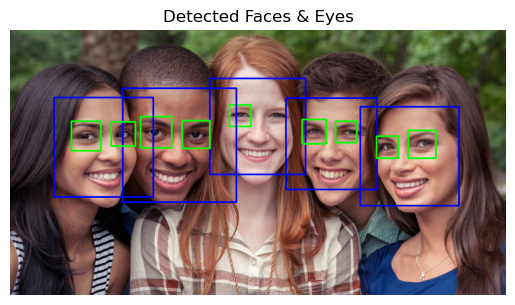

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load Haar cascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Load image
img = cv2.imread("image.png")

# Safety check
if img is None:
    raise FileNotFoundError("Image not found. Check the path and filename!")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.2, 5)

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    roi_gray = gray[y:y + h, x:x + w]
    roi_color = img[y:y + h, x:x + w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

# Convert BGR → RGB (for matplotlib correct colors)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image with matplotlib
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Detected Faces & Eyes")
plt.show()


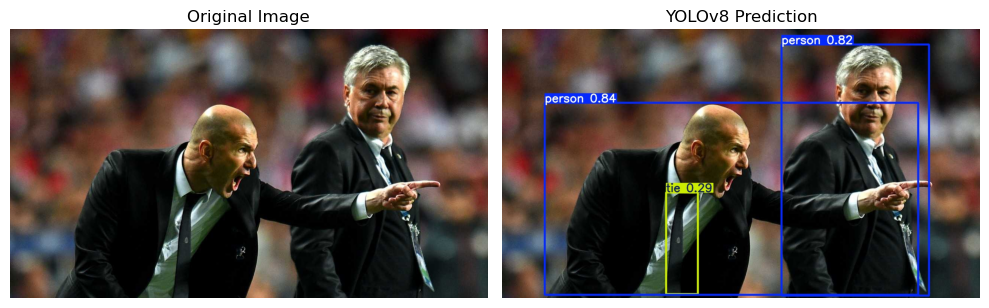

In [7]:
import matplotlib.pyplot as plt

img1 = cv2.imread("zidane.jpg")
img2 = cv2.imread("C:/code/21_days_21_projects/day12/runs/detect/predict/zidane.jpg")

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the images in the subplots
axes[0].imshow(img1_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off') # Hide axes

axes[1].imshow(img2_rgb)
axes[1].set_title("YOLOv8 Prediction")
axes[1].axis('off') # Hide axes

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()


image 1/1 c:\code\21_days_21_projects\day12\zidane.jpg: 384x640 2 persons, 1 tie, 88.3ms
Speed: 3.1ms preprocess, 88.3ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


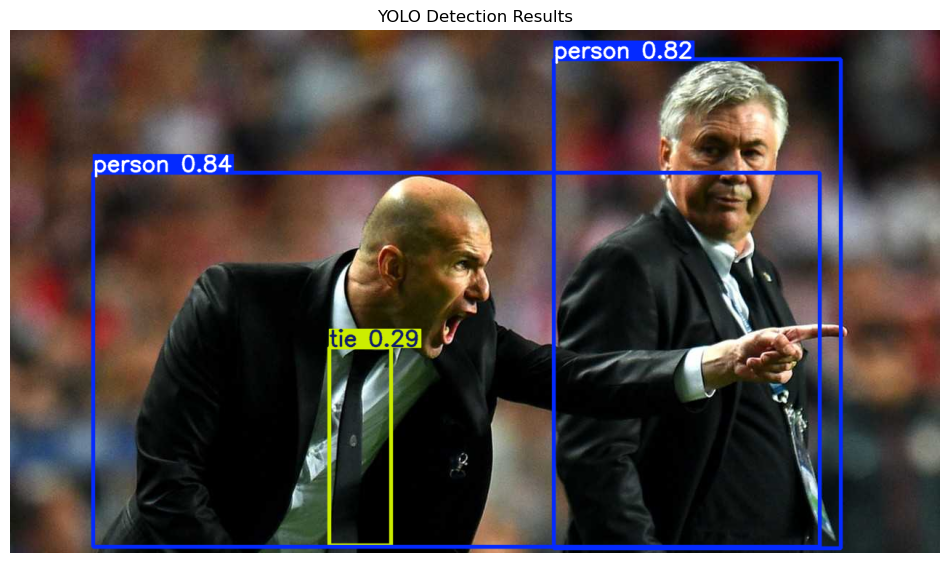

In [10]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load the YOLO model
model = YOLO('yolov8n.pt')

# Run inference on the image
results = model('zidane.jpg')  # Use your local file

# Get the annotated image
annotated_img = results[0].plot()

# Convert BGR to RGB for matplotlib (OpenCV uses BGR, matplotlib uses RGB)
img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Display using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title('YOLO Detection Results')
plt.axis('off')
plt.show()
